# 실습 4-2 : Under/Over Sampling (AI4I 데이터 버전)

#### **<실습 내용>**

1. 클래스 불균형 데이터 확인
- t-SNE를 통한 시각화

2. Resampling 기법 적용
- Random Undersampling
- TomekLinks (Undersampling)
- SMOTE (Oversampling)
- SMOTE + TomekLinks (복합 Resampling)
- ADASYN (Oversampling)

3. Resampling 전후 T-SNE 및 성능 비교

## 분석 준비

### 주요 라이브러리 호출

In [1]:
# 실행해서 설치해주세요.
! pip install imbalanced-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.manifold import TSNE

from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### 데이터 불러오기

In [4]:
data = pd.read_csv("dataset/day4-2_data.csv")

# 고장 유형 컬럼(TWF~RNF)은 Machine failure 여부와 직접 연관되어 정보 누수가 발생하므로 제거
data = data.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

# Type(범주형)은 원-핫 인코딩
data = pd.get_dummies(data, columns=["Type"], drop_first=True)

print("데이터 크기:", data.shape)
print("결측치 수:", data.isnull().sum().sum())
data.head()

데이터 크기: (10000, 8)
결측치 수: 0


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


---

## 1) 클래스 불균형 확인

> **클래스 불균형(Class Imbalance)** 이란 정상 데이터의 양이 불량 데이터보다 훨씬 많은 상황을 의미함
> - 해결 기법: **Resampling** (Under/Over Sampling) 또는 **One-Class Learning Model**

In [5]:
X = data.drop(["Machine failure"], axis=1)  # 타겟 컬럼 제외한 나머지를 입력 변수로 사용
Y = data["Machine failure"]

In [6]:
print("클래스 분포:")
print(Y.value_counts())  # 클래스별 개수 확인

클래스 분포:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [7]:
print("클래스 비율:")
print(np.round(Y.value_counts(normalize=True), 3))  # 클래스별 비율 확인 (소수점 3자리)

클래스 비율:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


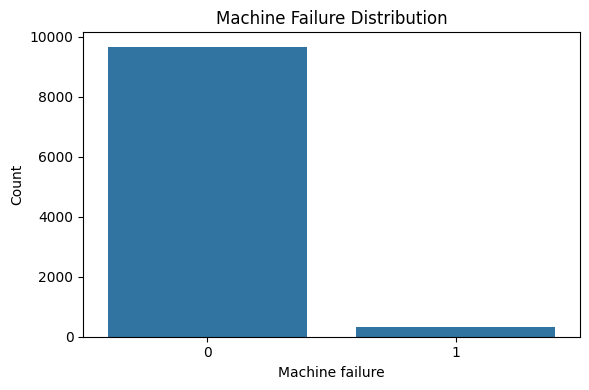

In [8]:
# 클래스 분포 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=Y.value_counts().index, y=Y.value_counts().values)  # 클래스별 개수를 막대그래프로 표시
plt.title("Machine Failure Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 1-1) t-SNE를 통한 시각화

> **t-SNE**는 고차원 데이터를 2차원으로 매핑하여 시각화하는 기법임
> - 클래스 간 분리 정도를 시각적으로 확인할 수 있음
> - 분리가 잘 될수록 분류 모델이 두 클래스를 구분하기 쉬운 데이터라는 뜻임

In [ ]:
from sklearn.manifold import TSNE

In [9]:
# n_components=2 : 원래 수백 개 특성을 가진 데이터를 2차원 좌표(x, y)로 압축
# fit_transform(X) : X를 학습하면서 동시에 2차원 좌표로 변환

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
X_embedded

array([[ 19.73424  , -61.158875 ],
       [-61.846077 , -55.196808 ],
       [ -6.1263146, -66.062004 ],
       ...,
       [ 53.29652  , -37.41317  ],
       [-53.81907  , -48.92215  ],
       [ -4.4799647, -56.61547  ]], dtype=float32)

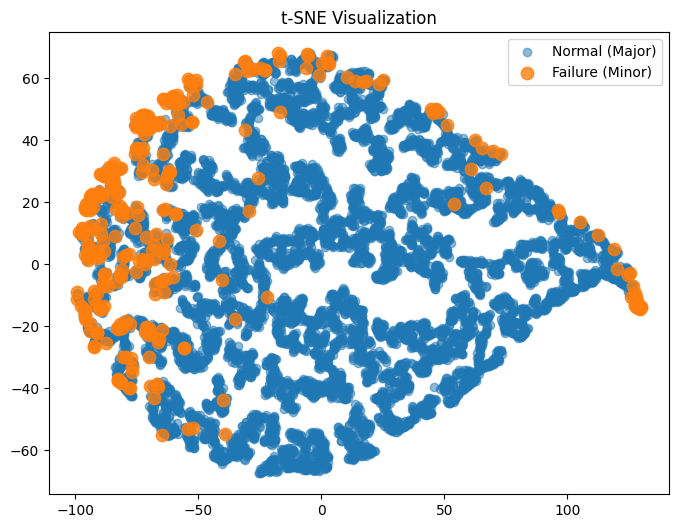

In [10]:
plt.figure(figsize=(8, 6))
# X_embedded[Y == 0, 0] : Normal 클래스(Y=0)의 x좌표, X_embedded[Y == 0, 1] : y좌표
plt.scatter(X_embedded[Y == 0, 0], X_embedded[Y == 0, 1], label='Normal (Major)', alpha=0.5)  # 다수 클래스(정상) 산점도
# X_embedded[Y == 1, 0] : Failure 클래스(Y=1)의 x좌표, X_embedded[Y == 1, 1] : y좌표
plt.scatter(X_embedded[Y == 1, 0], X_embedded[Y == 1, 1], label='Failure (Minor)', alpha=0.8, s=80)  # 소수 클래스(고장) 산점도, 점 크기 크게
plt.legend()
plt.title("t-SNE Visualization")
plt.show()

---

## 2) Resampling 기법 적용

| 기법 | 유형 | 설명 |
|---|---|---|
| TomekLinks | Undersampling | 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함 |
| SMOTE | Oversampling | 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄 |
| SMOTE + TomekLinks | 복합 Resampling | SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함 |
| ADASYN | Oversampling | SMOTE와 비슷하지만 구분이 어려운 샘플 주변에 더 많은 가상 샘플을 만들어냄 |

> Resampling은 **학습 데이터에만** 적용하고, 테스트 데이터는 원본 그대로 유지해야 함

In [11]:
# test는 실제 환경과 동일한 불균형 상태를 유지해야 모델 성능을 제대로 평가할 수 있음

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("학습 데이터 클래스 분포:")
print(Y_train.value_counts())

학습 데이터 클래스 분포:
Machine failure
0    7729
1     271
Name: count, dtype: int64


### 2-1) TomekLinks (Undersampling)

> **Tomek Links**는 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함

In [12]:
X_TomekLinks, Y_TomekLinks = TomekLinks().fit_resample(X_train, Y_train)  # TomekLinks로 다수 클래스 일부 제거 (undersampling)

# 적용 전/후 클래스별 개수 비교
compare_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_TomekLinks.value_counts()})
compare_TL["변화"] = compare_TL["적용 후"] - compare_TL["적용 전"]  # 클래스별 변화량 계산
compare_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7641,-88
1,271,271,0


### 2-2) SMOTE (Oversampling)

> **SMOTE**는 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄

In [13]:
X_SMOTE, Y_SMOTE = SMOTE().fit_resample(X_train, Y_train)  # SMOTE로 소수 클래스를 다수 클래스 수만큼 늘림 (oversampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTE.value_counts()})
compare_SMOTE["변화"] = compare_SMOTE["적용 후"] - compare_SMOTE["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7729,7458


### 2-3) SMOTE + TomekLinks (복합 Resampling)

> SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함

In [14]:
X_SMOTETomek, Y_SMOTETomek = SMOTETomek().fit_resample(X_train, Y_train)  # SMOTE로 늘린 뒤 TomekLinks로 겹치는 샘플 정리 (복합 resampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTETomek.value_counts()})
compare_SMOTE_TL["변화"] = compare_SMOTE_TL["적용 후"] - compare_SMOTE_TL["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7652,-77
1,271,7652,7381


### 2-4) ADASYN (Oversampling)

> **ADASYN**은 SMOTE를 개선한 기법으로, 다수 클래스와 인접한 소수 클래스 샘플 주변에 더 많은 데이터를 생성함
> - 즉 분류가 어려운 경계 영역에 집중적으로 데이터를 증강함

In [15]:
X_ADASYN, Y_ADASYN = ADASYN(random_state=42).fit_resample(X_train, Y_train)  # ADASYN으로 소수 클래스를 다수 클래스 수만큼 늘림 (경계 근처에 더 많이 생성)

# 적용 전/후 클래스별 개수 비교
compare_ADA = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_ADASYN.value_counts()})
compare_ADA["변화"] = compare_ADA["적용 후"] - compare_ADA["적용 전"]  # 클래스별 변화량 계산
compare_ADA

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7671,7400


> 기본 설정 기준: `sampling_strategy ='auto'`
> - 1:1이 되는 기법: SMOTE, SMOTE+TomekLinks
> - 1:1이 아닌 기법: TomekLinks (다수 클래스 일부만 제거), ADASYN (경계 근처 위주로 생성되어 정확히 1:1은 아님)

---

## 3) Resampling 결과 분석

### 3-1) Sampling 전후 t-SNE 비교

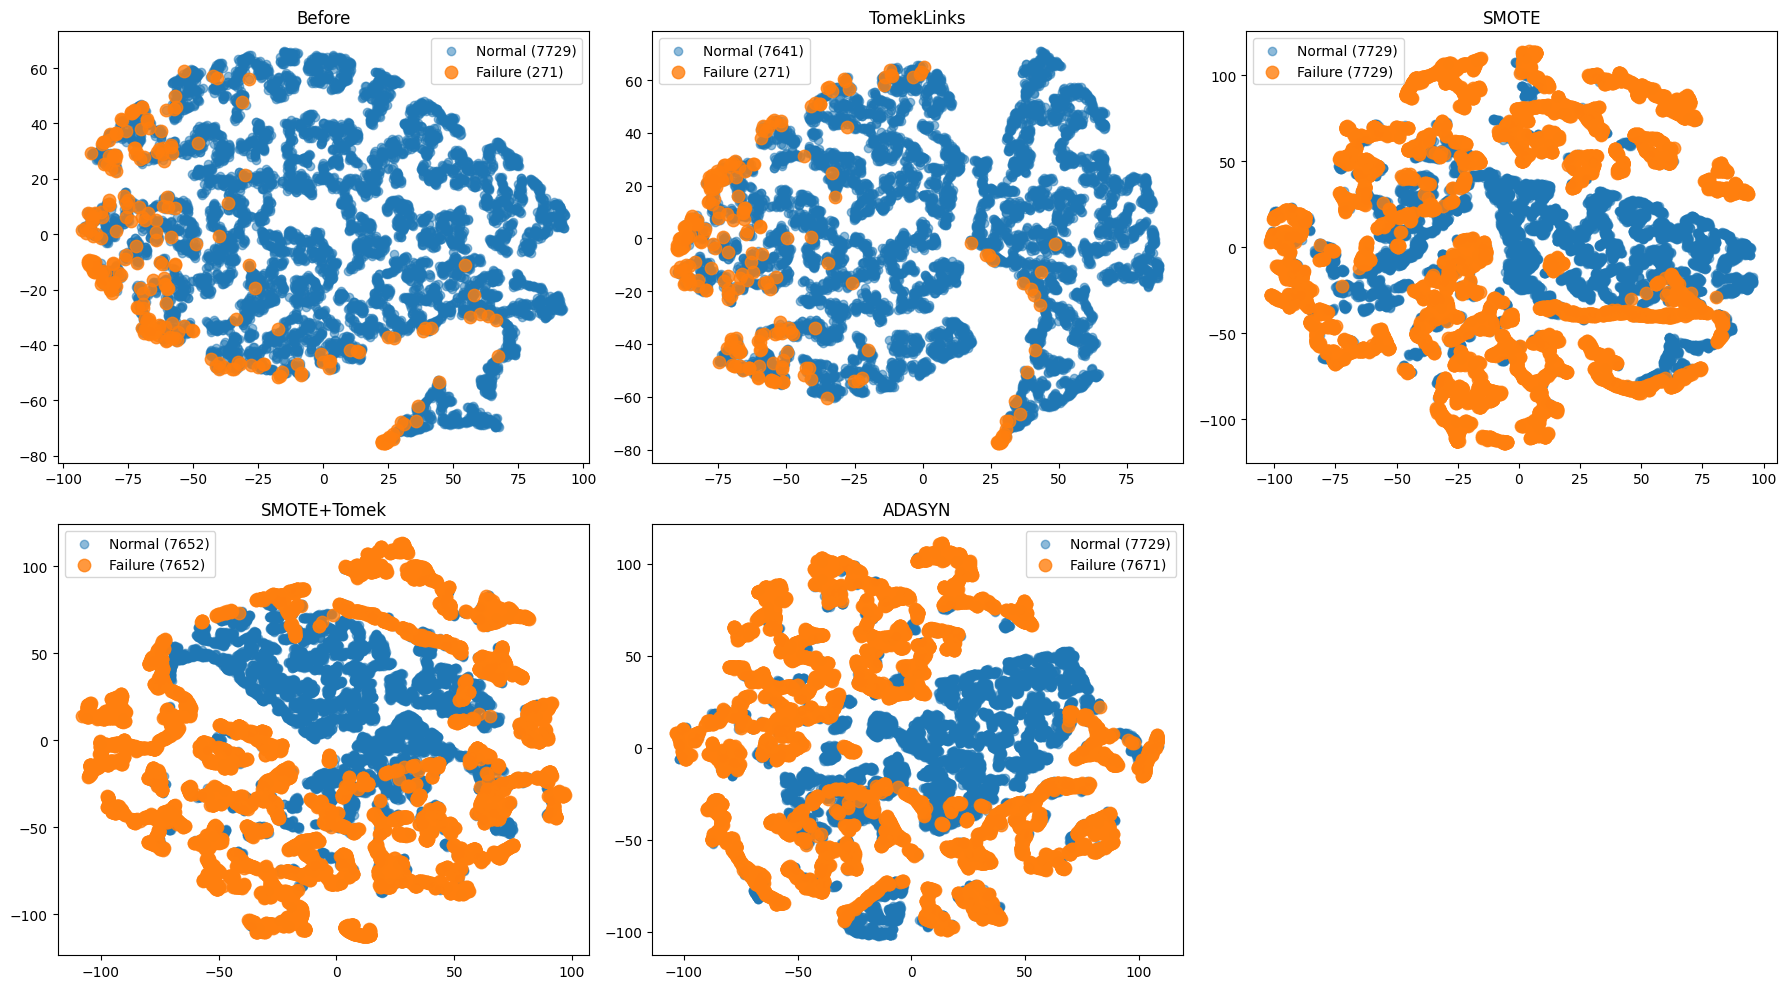

In [16]:
# 방법론별 t-SNE 비교 (Normal vs Failure)
A, B = 0, 1  # Normal, Failure

sampling_datasets = {
    "Before": (X_train, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, init='random', learning_rate='auto', perplexity=30, random_state=42).fit_transform(X_s)
    axes[i].scatter(emb[Y_s.values == A, 0], emb[Y_s.values == A, 1], label=f'Normal ({(Y_s==A).sum()})', alpha=0.5)
    axes[i].scatter(emb[Y_s.values == B, 0], emb[Y_s.values == B, 1], label=f'Failure ({(Y_s==B).sum()})', alpha=0.8, s=80)
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 3-2) Sampling 전후 성능 비교

In [17]:
from xgboost import XGBClassifier

results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():

    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    scale_pos_weight = neg / pos  # 불균형 비율 반영

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test)
    results.append({
        "Method": name,
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 4)
    })

pd.DataFrame(results)

,Method,Precision,Recall,F1-score
0,Before,0.7027,0.7647,0.7324
1,TomekLinks,0.7432,0.8088,0.7746
2,SMOTE,0.5638,0.7794,0.6543
3,SMOTE+Tomek,0.5955,0.7794,0.6752
4,ADASYN,0.5400,0.7941,0.6429


---

## 4) Vibe Coding 실습

**[과제 1]**
지수는 위 t-SNE 시각화 결과(Before / TomekLinks / SMOTE / SMOTE+Tomek / ADASYN)를 보고, Resampling 기법마다 Normal과 Failure 클래스가 어떻게 다르게 분포하는지 궁금해졌습니다.

AI에게 이미지를 보여주며 각 기법의 결과가 어떤 의미를 갖는지 해석을 요청하고 원본 데이터에서 Failure 데이터가 339개(전체의 3.4%)뿐이라는 점을 함께 고려했을 때 이 문제에는 Resampling과 One-Class Learning 중 어떤 접근이 더 적합할지 AI와 논의해 보세요.

t-SNE 결과 해석 및 접근법 권장
1. 각 Resampling 기법 t-SNE 해석
그래프는 학습 데이터(train, 80%) 기준이며, 원본 전체 Failure 339개 중 train에는 약 271개가 들어 있습니다.

Before (원본 학습 데이터)
Normal 7,729 / Failure 271 — 약 28:1 불균형
파란 점(Normal)이 넓고 조밀한 영역을 차지하고, 주황 점(Failure)은 수가 적고 왼쪽·아래 등 일부 구역에 흩어져 있음
의미: 고장 샘플이 정상 데이터 안쪽·경계에 섞여 있어, 단순히 클래스 개수만 맞추기 어려운 문제
Failure가 완전히 분리되지 않았으므로, 어떤 방법을 쓰든 오분류(특히 False Positive) 가 나오기 쉬운 구조

TomekLinks (Undersampling)
Normal 7,641 / Failure 271 — Normal만 약 88개 감소
전체 모양은 Before와 거의 같고, 시각적 변화는 작음
의미: 서로 다른 클래스의 가장 가까운 이웃 쌍에서 다수 클래스(Normal)만 제거해 경계를 조금 정리
Failure는 그대로이므로 소수 클래스 정보는 보존
불균형 비율은 거의 그대로 → 개수 불균형 자체는 해결되지 않음

SMOTE (Oversampling)
Normal 7,729 / Failure 7,729 — 1:1 균형
주황 점이 크게 늘고, 원래 Failure 주변·사이를 보간한 합성 샘플이 채워짐
파란 영역 안으로 주황이 깊게 침투해 겹침이 커짐
의미: train Failure가 271개뿐인데 7,000개 이상 합성 → 소수 클래스를 인위적으로 늘림
t-SNE상 겹침이 과장될 수 있고, 실제 고장 패턴과 다른 가짜 Failure 가 많아질 위험

SMOTE + TomekLinks (복합)
Normal 7,652 / Failure 7,652 — 1:1이지만 SMOTE만큼은 아님
SMOTE 후 TomekLinks로 애매한 경계 샘플을 정리
SMOTE보다 주황·파랑 경계가 조금 덜 지저분
의미: Oversampling + 경계 정리로 SMOTE 단독보다 결정 경계가 깔끔해질 여지가 있음
그래도 Failure 합성량이 크고, Before에서 보인 본질적 겹침은 크게 사라지지 않음

ADASYN (Adaptive Oversampling)
Normal 7,729 / Failure 7,671 — 거의 1:1 (ADASYN 특성상 정확히 1:1은 아님)
SMOTE와 비슷하지만, 다수 클래스와 가까운(분류 어려운) Failure 주변에 합성 샘플을 더 많이 생성
원래 고립된 Failure·경계 쪽에 주황 밀도가 높음
의미: “어려운 구간”에 집중 증강 → 경계 학습에는 유리할 수 있으나, 그 구간이 노이즈면 과적합 위험도 큼
t-SNE 해석 시 주의점
t-SNE는 시각화용이라 Resampling 전후 좌표계가 달라 직접 비교는 제한적입니다.
그래도 공통적으로 보이는 점은, Oversampling 계열은 Failure 점이 폭증하고 Normal과 겹침이 커진다는 것입니다.

이 데이터( Failure 339개, 3.4% )에는 One-Class Learning이 더 적합
극심한 불균형 (3.4%)
SMOTE/ADASYN은 소수 클래스를 25배 이상 늘립니다. 고장 유형이 다양하면 합성 샘플이 실제 고장을 잘 대표하지 못할 가능성이 큽니다.

t-SNE의 겹침
Before에서도 Failure가 Normal 영역에 섞여 있습니다. Oversampling은 이 겹침을 더 키우는 방향으로 보입니다.
One-Class는 “정상 영역”을 학습하고, 그 밖을 고장 후보로 보는 문제 정의 전환에 가깝습니다.

제조 고장 탐지 맥락
정상 가동 데이터는 많고, 고장은 드묾 → 이상 탐지(Anomaly Detection) 프레이밍이 자연스럽습니다.
실습 4-3 SVDD(One-Class SVM) 와도 이어집니다.

Resampling이 여전히 쓸 만한 경우

고장 패턴이 안정적이고 Failure끼리 뭉쳐 있을 때
Recall을 극대화해야 할 때 (오탐 비용 < 미탐 비용)
XGBoost + scale_pos_weight 같은 비용 민감 학습과 병행할 때
현재 t-SNE는 분리가 약하고 Failure가 Normal에 묻혀 있어, Resampling만으로는 한계가 큽니다.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ===== 1. Day 4-2와 동일한 전처리 =====
data = pd.read_csv("dataset/day4-2_data.csv")
data = data.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])
data = pd.get_dummies(data, columns=["Type"], drop_first=True)

X = data.drop(["Machine failure"], axis=1)
Y = data["Machine failure"]  # 0=Normal, 1=Failure

# ===== 2. train/test 분리 (Resampling과 동일하게 stratify) =====
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# ===== 3. 정상(Normal) 데이터만으로 학습 =====
X_train_normal = X_train[Y_train == 0]
print(f"학습(정상만): {X_train_normal.shape}")
print(f"테스트: {X_test.shape} (Failure: {(Y_test == 1).sum()}개)")

# SVM은 스케일에 민감 → 반드시 표준화
scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

# ===== 4. One-Class SVM (SVDD) 학습 =====
# nu: 학습 데이터 중 이상치로 허용할 비율 상한
# 실제 Failure 비율(~3.4%)을 참고해 0.03~0.05 근처에서 튜닝
oc_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",      # 또는 "auto"
    nu=0.034            # 전체 Failure 비율과 유사하게 시작
)
oc_svm.fit(X_train_normal_scaled)

# ===== 5. 예측 및 라벨 변환 =====
# OneClassSVM: +1 = inlier(정상), -1 = outlier(이상/고장)
Y_pred_raw = oc_svm.predict(X_test_scaled)
Y_pred = np.where(Y_pred_raw == -1, 1, 0)  # -1 → Failure(1), +1 → Normal(0)

# ===== 6. 성능 평가 (Failure=1 기준) =====
print("=== One-Class SVM (SVDD) 성능 ===")
print(f"Accuracy  : {accuracy_score(Y_test, Y_pred):.4f}")
print(f"Precision : {precision_score(Y_test, Y_pred, pos_label=1):.4f}")
print(f"Recall    : {recall_score(Y_test, Y_pred, pos_label=1):.4f}")
print(f"F1-score  : {f1_score(Y_test, Y_pred, pos_label=1):.4f}")
print("\n혼동행렬:")
print(confusion_matrix(Y_test, Y_pred))
print("\n", classification_report(Y_test, Y_pred, target_names=["Normal", "Failure"]))

# ===== 7. nu 튜닝 (선택) =====
results = []
for nu in [0.01, 0.02, 0.034, 0.05, 0.1, 0.15]:
    model = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    model.fit(X_train_normal_scaled)
    pred_raw = model.predict(X_test_scaled)
    pred = np.where(pred_raw == -1, 1, 0)
    results.append({
        "nu": nu,
        "Precision": round(precision_score(Y_test, pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1, zero_division=0), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1, zero_division=0), 4),
    })

pd.DataFrame(results)

학습(정상만): (7729, 7)
테스트: (2000, 7) (Failure: 68개)
=== One-Class SVM (SVDD) 성능 ===
Accuracy  : 0.9380
Precision : 0.2500
Recall    : 0.4118
F1-score  : 0.3111

혼동행렬:
[[1848   84]
 [  40   28]]

               precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      1932
     Failure       0.25      0.41      0.31        68

    accuracy                           0.94      2000
   macro avg       0.61      0.68      0.64      2000
weighted avg       0.95      0.94      0.95      2000



,nu,Precision,Recall,F1-score
0,0.010,0.4528,0.3529,0.3967
1,0.020,0.3521,0.3676,0.3597
2,0.034,0.2500,0.4118,0.3111
3,0.050,0.2254,0.4706,0.3048
4,0.100,0.1581,0.5882,0.2492
5,0.150,0.1324,0.7206,0.2237


In [20]:
# ===== 추가 import (라이브러리 셀에 넣거나 여기서 import) =====
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from xgboost import XGBClassifier

# ===== 공통 평가 함수 =====
def evaluate_failure(y_true, y_pred, method, approach):
    """Failure(1) 기준 지표 계산"""
    return {
        "Method": method,
        "Approach": approach,  # Resampling / One-Class
        "Precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "F1-score": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
    }

all_results = []

# ============================================================
# 1) Resampling + XGBoost (기존 노트북과 동일)
# ============================================================
for name, (X_tr, Y_tr) in sampling_datasets.items():
    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    scale_pos_weight = neg / pos

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test)

    all_results.append(evaluate_failure(Y_test, pred, name, "Resampling + XGBoost"))

# ============================================================
# 2) One-Class Learning (SVDD / OneClassSVM)
#    - 정상(Normal, Y=0)만으로 학습
#    - 테스트는 원본 X_test, Y_test 그대로 사용
# ============================================================
X_train_normal = X_train[Y_train == 0]

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

# Failure 비율(~3.4%)을 반영한 기본 nu
oc_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.034)
oc_svm.fit(X_train_normal_scaled)

pred_raw = oc_svm.predict(X_test_scaled)
pred_oc = np.where(pred_raw == -1, 1, 0)  # -1 → Failure(1), +1 → Normal(0)

all_results.append(
    evaluate_failure(Y_test, pred_oc, "One-Class SVM (nu=0.034)", "One-Class Learning")
)

# ============================================================
# 3) 결과 정리 및 출력
# ============================================================
compare_df = pd.DataFrame(all_results).sort_values("F1-score", ascending=False).reset_index(drop=True)
compare_df

,Method,Approach,Precision,Recall,F1-score
0,TomekLinks,Resampling + XGBoost,0.7432,0.8088,0.7746
1,Before,Resampling + XGBoost,0.7027,0.7647,0.7324
2,SMOTE+Tomek,Resampling + XGBoost,0.5955,0.7794,0.6752
3,SMOTE,Resampling + XGBoost,0.5638,0.7794,0.6543
4,ADASYN,Resampling + XGBoost,0.5400,0.7941,0.6429
5,One-Class SVM (nu=0.034),One-Class Learning,0.2500,0.4118,0.3111


C:\Users\Admin\AppData\Local\Temp\ipykernel_23616\416940979.py:17: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_23616\416940979.py:17: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_23616\416940979.py:17: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_23616\416940979.py:17: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages\IPython\core\pylabtools.py:152: User

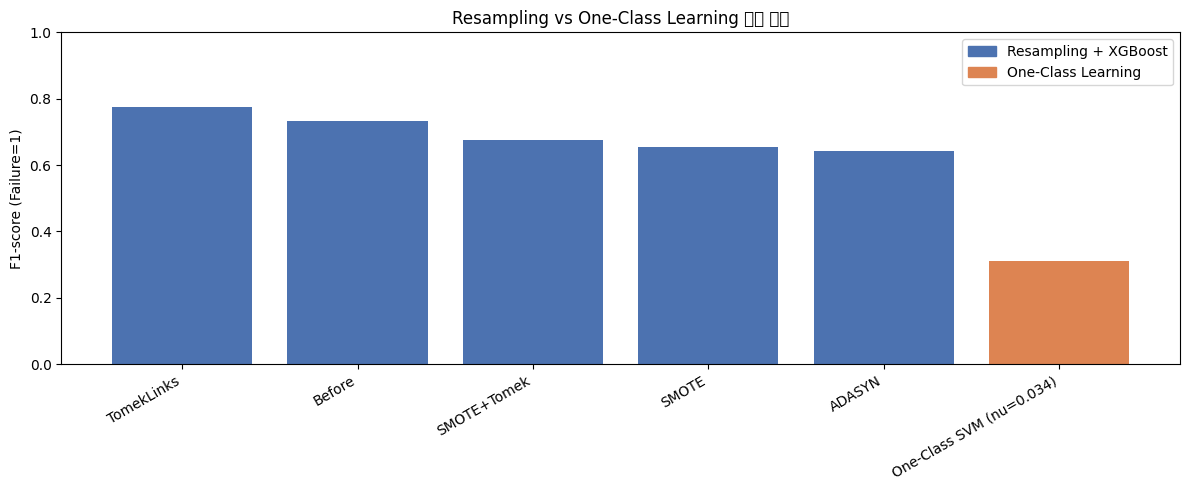

In [21]:
# F1-score 막대그래프
plt.figure(figsize=(12, 5))
colors = ["#4C72B0" if a == "Resampling + XGBoost" else "#DD8452" 
          for a in compare_df["Approach"]]

plt.bar(compare_df["Method"], compare_df["F1-score"], color=colors)
plt.xticks(rotation=30, ha="right")
plt.ylabel("F1-score (Failure=1)")
plt.title("Resampling vs One-Class Learning 성능 비교")
plt.ylim(0, 1)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="#4C72B0", label="Resampling + XGBoost"),
    Patch(color="#DD8452", label="One-Class Learning")
])
plt.tight_layout()
plt.show()